In [1]:
import pandas as pd

inventory_df = pd.read_csv(
    "Data/Processed/lstm_forecast.csv"
)

inventory_df.head()

,Date,Actual Sales,Predicted Sales
0,2011-08-11,54325.271921,24739.509467
1,2011-08-12,17970.170221,20383.457883
2,2011-08-14,5701.870077,16984.397731
3,2011-08-15,17235.950627,23439.708979
4,2011-08-16,16072.709543,22190.506167


In [2]:
inventory_df.rename(
    columns={
        "Predicted Sales":"Forecast_Demand"
    },
    inplace=True
)

inventory_df.head()

,Date,Actual Sales,Forecast_Demand
0,2011-08-11,54325.271921,24739.509467
1,2011-08-12,17970.170221,20383.457883
2,2011-08-14,5701.870077,16984.397731
3,2011-08-15,17235.950627,23439.708979
4,2011-08-16,16072.709543,22190.506167


In [3]:
# average daily demand
average_demand = inventory_df[
    "Forecast_Demand"
].mean()

print(
    "Average Daily Demand:",
    round(average_demand,2)
)

Average Daily Demand: 35238.34


In [4]:
# standard deviation 
demand_std = inventory_df[
    "Forecast_Demand"
].std()

print(
    "Demand Std:",
    round(demand_std,2)
)

Demand Std: 13504.87


In [5]:
# bussiness assumptions 
lead_time = 7

service_factor = 1.65

In [6]:
# Safety stock 
import numpy as np

safety_stock = (
    service_factor
    *
    demand_std
    *
    np.sqrt(lead_time)
)

print(
    "Safety Stock:",
    round(safety_stock,2)
)

Safety Stock: 58955.38


In [7]:
# reorder point 
reorder_point = (
    average_demand
    *
    lead_time
) + safety_stock

print(
    "Reorder Point:",
    round(reorder_point,2)
)

Reorder Point: 305623.74


In [8]:
# Recommended order quantity 
recommended_order = (
    average_demand
    *
    lead_time
)

print(
    "Recommended Order Quantity:",
    round(recommended_order,2)
)

Recommended Order Quantity: 246668.36


In [9]:
inventory_summary = pd.DataFrame({
    "Metric":[
        "Average Daily Demand",
        "Demand Std Dev",
        "Lead Time",
        "Safety Stock",
        "Reorder Point",
        "Recommended Order Quantity"
    ],
    "Value":[
        round(average_demand,2),
        round(demand_std,2),
        lead_time,
        round(safety_stock,2),
        round(reorder_point,2),
        round(recommended_order,2)
    ]
})

inventory_summary

,Metric,Value
0,Average Daily Demand,35238.34
1,Demand Std Dev,13504.87
2,Lead Time,7.00
3,Safety Stock,58955.38
4,Reorder Point,305623.74
5,Recommended Order Quantity,246668.36


In [12]:
inventory_summary.to_csv(
    "Data/Processed/inventory_summary.csv",
    index=False
)

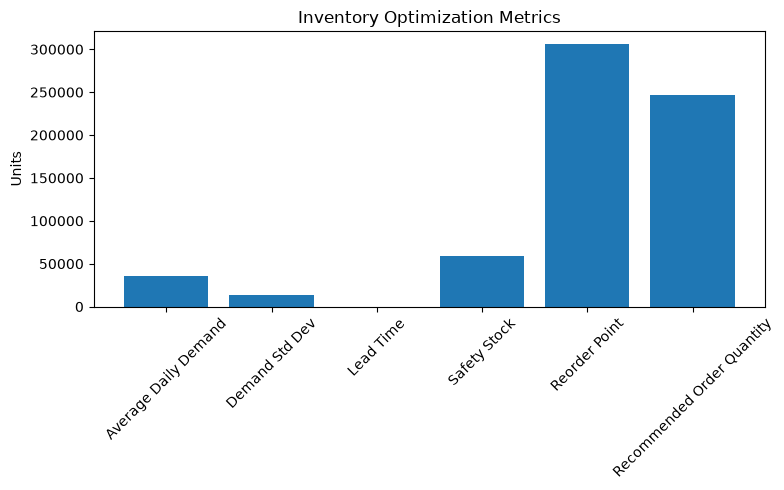

In [11]:
import matplotlib.pyplot as plt
plot_df = inventory_summary[
    inventory_summary["Metric"] != "Lead Time (Days)"
]

plt.figure(figsize=(8,5))

plt.bar(
    plot_df["Metric"],
    plot_df["Value"]
)

plt.xticks(rotation=45)

plt.ylabel("Units")

plt.title("Inventory Optimization Metrics")

plt.tight_layout()

plt.show()

## Inventory Optimization Summary

The demand forecast generated by the Multivariate LSTM model was used to calculate inventory planning metrics.

Assumptions:
• Lead Time = 7 days
• Service Level = 95%

Results:
• Average Daily Demand = 35,238 units
• Safety Stock = 58,955 units
• Reorder Point = 305,624 units
• Recommended Order Quantity = 246,668 units

These metrics help businesses maintain sufficient inventory, reduce stockouts, and improve inventory planning.